--- QBCA FINAL PERFORMANCE REPORT ---
                    Metric Your Implementation Paper Benchmark (G5)
   Initialization Time (s)             0.01143              0.00396
    Average Distortion (φ)            0.003899             0.007487
Avg. Distance Computations                0.29                ~1.50
        Total CPU Time (s)              0.0964              ~0.0400


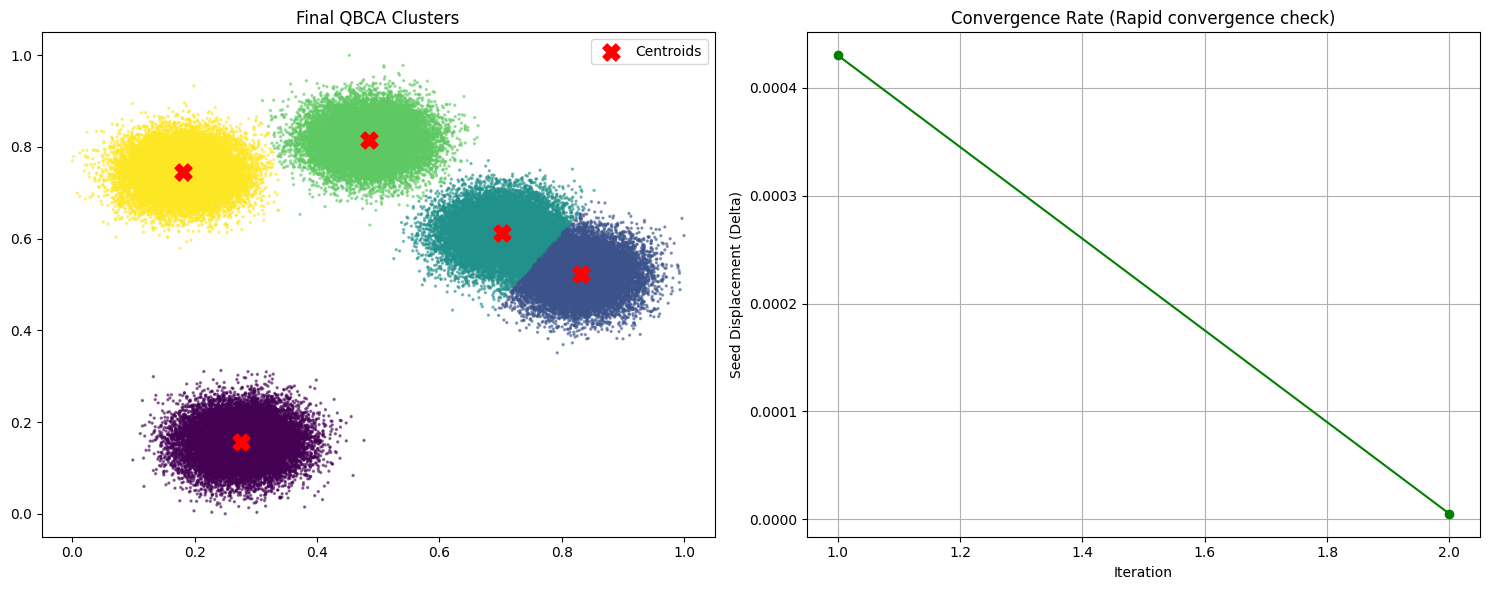

<Figure size 640x480 with 0 Axes>

In [1]:
"""QBCA analysis notebook."""

import time

import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import arff

from sklearn.datasets import make_blobs, load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import rand_score

from qbca import QBCA

# Generate synthetic data to match "Gaussian (5)"
n_samples = 100000
X_raw, _ = make_blobs(n_samples=n_samples, centers=5, n_features=2, random_state=42)

# Scale the data to [0, 1] so the spatial distortion
# matches the mathematical scale of the paper's G5 dataset.
scaler = MinMaxScaler()
X = scaler.fit_transform(X_raw)

# A threshold of 1e-5 is more appropriate to ensure full convergence.
model = QBCA(k=5, threshold=0.00001, max_iter=30)
start_total = time.time()
labels, centers, history = model.fit(X)
end_total = time.time()

# Metric Calculation
avg_distortion, avg_dist_comp = model.get_metrics(X, labels)
total_cpu_time = end_total - start_total

# Comparative Report Generation
report_data = {
    "Metric": [
        "Initialization Time (s)",
        "Average Distortion (φ)",
        "Avg. Distance Computations",
        "Total CPU Time (s)"
    ],
    "Your Implementation": [
        f"{model.init_time:.5f}",
        f"{avg_distortion:.6f}",
        f"{avg_dist_comp:.2f}",
        f"{total_cpu_time:.4f}"
    ],
    "Paper Benchmark (G5)": [
        "0.00396",
        "0.007487",
        "~1.50",
        "~0.0400"
    ]
}

df_report = pd.DataFrame(report_data)
print("--- QBCA FINAL PERFORMANCE REPORT ---")
print(df_report.to_string(index=False))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Cluster Plot
ax1.scatter(X[:, 0], X[:, 1], c=labels, s=2, cmap='viridis', alpha=0.5)
ax1.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=150, label='Centroids')
ax1.set_title("Final QBCA Clusters")
ax1.legend()

# Convergence Plot
shifts = [h['shift'] for h in history]
ax2.plot(range(1, len(shifts) + 1), shifts, marker='o', color='green')
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Seed Displacement (Delta)")
ax2.set_title("Convergence Rate (Rapid convergence check)")
ax2.grid(True)

plt.tight_layout()

plt.show()
plt.tight_layout()
plt.show()

In [2]:
def evaluate_iris():
    """Load Iris from sklearn, scales it, and evaluates QBCA."""
    print("Loading Iris from sklearn...")
    data = load_iris()
    X_raw = data.data
    true_labels = data.target

    # Scale data to [0, 1]
    scaler = MinMaxScaler()
    X = scaler.fit_transform(X_raw)

    # Run QBCA (k=3 for 3 species of Iris)
    model = QBCA(k=3, threshold=0.00001, max_iter=50)

    start_time = time.time()
    predicted_labels, _, _ = model.fit(X)
    cpu_time = time.time() - start_time

    # Calculate Rand Index
    ri = rand_score(true_labels, predicted_labels)
    return ri, cpu_time

def evaluate_wine_arff(filepath):
    """Load Wine from local ARFF file, scales it, and evaluates QBCA."""
    print(f"Loading Wine from {filepath}...")
    # Load the ARFF file
    data, meta = arff.loadarff(filepath)
    df = pd.DataFrame(data)

    # ARFF files usually name the target column 'class'.
    # Change 'class' below if your file uses a different column name for the label!
    target_col = 'class'

    y_raw = df[target_col].values
    X_raw = df.drop(columns=[target_col]).values

    # Convert categorical labels (which ARFF often loads as byte strings) into integers
    true_labels = pd.factorize(y_raw)[0]

    # Scale data to [0, 1]
    scaler = MinMaxScaler()
    X = scaler.fit_transform(X_raw)

    # Run QBCA (k=3 for 3 types of wine)
    model = QBCA(k=3, threshold=0.00001, max_iter=50)

    start_time = time.time()
    predicted_labels, _, _ = model.fit(X)
    cpu_time = time.time() - start_time

    # Calculate Rand Index
    ri = rand_score(true_labels, predicted_labels)
    return ri, cpu_time

# --- 1. Run the Evaluations ---
iris_ri, iris_time = evaluate_iris()

wine_ri, wine_time = evaluate_wine_arff('data/wine.arff')

# --- 2. Print Comparative Report ---
real_data_report = {
    "Dataset": ["Iris", "Wine"],
    "Your Accuracy (Rand Index)": [f"{iris_ri:.4f}", f"{wine_ri:.4f}"],
    "Paper Accuracy (Rand Index)": ["0.9436", "0.7187"],
    "Your CPU Time (s)": [f"{iris_time:.5f}", f"{wine_time:.5f}"],
    "Paper CPU Time (s)": ["0.00318", "0.00361"]
}

df_real = pd.DataFrame(real_data_report)
print("\n--- REAL WORLD DATASETS VALIDATION ---")
print(df_real.to_string(index=False))

Loading Iris from sklearn...
Loading Wine from data/wine.arff...

--- REAL WORLD DATASETS VALIDATION ---
Dataset Your Accuracy (Rand Index) Paper Accuracy (Rand Index) Your CPU Time (s) Paper CPU Time (s)
   Iris                     0.8679                      0.9436           0.00534            0.00318
   Wine                     0.9620                      0.7187           0.00730            0.00361
